# 08 - current champion, all available symbols, $1000 account

Run the live `strategies/volume_weighted_breakout/strategy.py` after promoting the short-cluster-guard champion. Universe is every symbol currently available on disk. Equity and benchmark are rebased to `$1000` for display.

In [1]:
import json
import sys; sys.path.insert(0, ".")
from _lab import *

symbols = list_symbols()
start, end = "2024-01-01", "2026-01-01"
initial_cash = 1000.0

print("strategy:", strategy.__name__)
print("tf:", strategy.DEFAULT_TF)
print("n symbols:", len(symbols))
print(symbols)
print("params:")
print(json.dumps(strategy.DEFAULT_PARAMS, indent=2))

strategy: strategy_volume_weighted_breakout
tf: 4h
n symbols: 95
['1000BONKUSDT', '1000PEPEUSDT', 'AAVEUSDT', 'ADAUSDT', 'AERGOUSDT', 'AIGENSYNUSDT', 'ALGOUSDT', 'ALLOUSDT', 'APTUSDT', 'ARBUSDT', 'AVAXUSDT', 'BASEDUSDT', 'BCHUSDT', 'BEATUSDT', 'BIRBUSDT', 'BNBUSDT', 'BOTUSDT', 'BREVUSDT', 'BTCUSDT', 'CAPUSDT', 'CLUSDT', 'CRVUSDT', 'DASHUSDT', 'DOGEUSDT', 'DOTUSDT', 'DRAMUSDT', 'DYDXUSDT', 'ENAUSDT', 'ENJUSDT', 'ETHUSDT', 'EWYUSDT', 'FARTCOINUSDT', 'GRAMUSDT', 'GRASSUSDT', 'HBARUSDT', 'HUSDT', 'HYPEUSDT', 'ICPUSDT', 'INJUSDT', 'INTCUSDT', 'INUSDT', 'JTOUSDT', 'JUPUSDT', 'KORUUSDT', 'LABUSDT', 'LINKUSDT', 'LITUSDT', 'LTCUSDT', 'METUSDT', 'MEUSDT', 'MNTUSDT', 'MRVLUSDT', 'MSTRUSDT', 'MUSDT', 'MUUSDT', 'NBISUSDT', 'NEARUSDT', 'NOMUSDT', 'ONDOUSDT', 'OPUSDT', 'PAXGUSDT', 'PENGUUSDT', 'PUMPFUNUSDT', 'PYTHUSDT', 'REUSDT', 'SKHYNIXUSDT', 'SLXUSDT', 'SNDKUSDT', 'SOLUSDT', 'SOXLUSDT', 'SPCXUSDT', 'SUIUSDT', 'TACUSDT', 'TAIKOUSDT', 'TAOUSDT', 'TIAUSDT', 'TLMUSDT', 'TONUSDT', 'TRUMPUSDT', 'TRXUSDT

In [2]:
coverage_table = pd.DataFrame(
    [(sym, *coverage(sym)) for sym in symbols],
    columns=["symbol", "first_month", "last_month", "n_months"],
).set_index("symbol")
coverage_table.sort_values(["n_months", "symbol"]).head(30)

,first_month,last_month,n_months
symbol,,,
BOTUSDT,2026-07,2026-07,1
CAPUSDT,2026-06,2026-07,2
GRAMUSDT,2026-06,2026-07,2
KORUUSDT,2026-06,2026-07,2
REUSDT,2026-06,2026-07,2
SKHYNIXUSDT,2026-06,2026-07,2
SLXUSDT,2026-06,2026-07,2
SPCXUSDT,2026-06,2026-07,2
DRAMUSDT,2026-05,2026-07,3


In [3]:
result = run_pair(symbols, start, end, return_curves=True)
metrics_frame(result)

,sharpe,sortino,max_dd,total_return,n_trades,pct_time_in_position,profit_factor
split,,,,,,,
train,1.962333,2.707974,0.039770,0.264523,3264,96.778116,1.284737
oos,-0.380921,-0.514161,0.099832,-0.030036,1472,99.361314,0.937177


In [4]:
curves = result["curves"]
equity = rebase(curves["equity"], initial_cash)
benchmark = rebase(curves["benchmark"], initial_cash)
raw_equity = rebase(curves["raw_equity"], initial_cash)
dd = drawdown(equity)
cutoff = curves["split_cutoff"]

summary = pd.Series({
    "n_symbols": len(symbols),
    "start_equity": equity.iloc[0],
    "end_equity": equity.iloc[-1],
    "total_return": equity.iloc[-1] / equity.iloc[0] - 1.0,
    "max_drawdown": dd.min(),
    "benchmark_end": benchmark.iloc[-1],
    "bars": len(equity),
})
summary

n_symbols          95.000000
start_equity     1000.000000
end_equity       1226.175333
total_return        0.226175
max_drawdown       -0.099832
benchmark_end    1455.005556
bars             4386.000000
dtype: float64

[saved] notebooks\volume_weighted_breakout\_out\08_current_champion_all_available_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/08_current_champion_all_available_equity_drawdown.png')

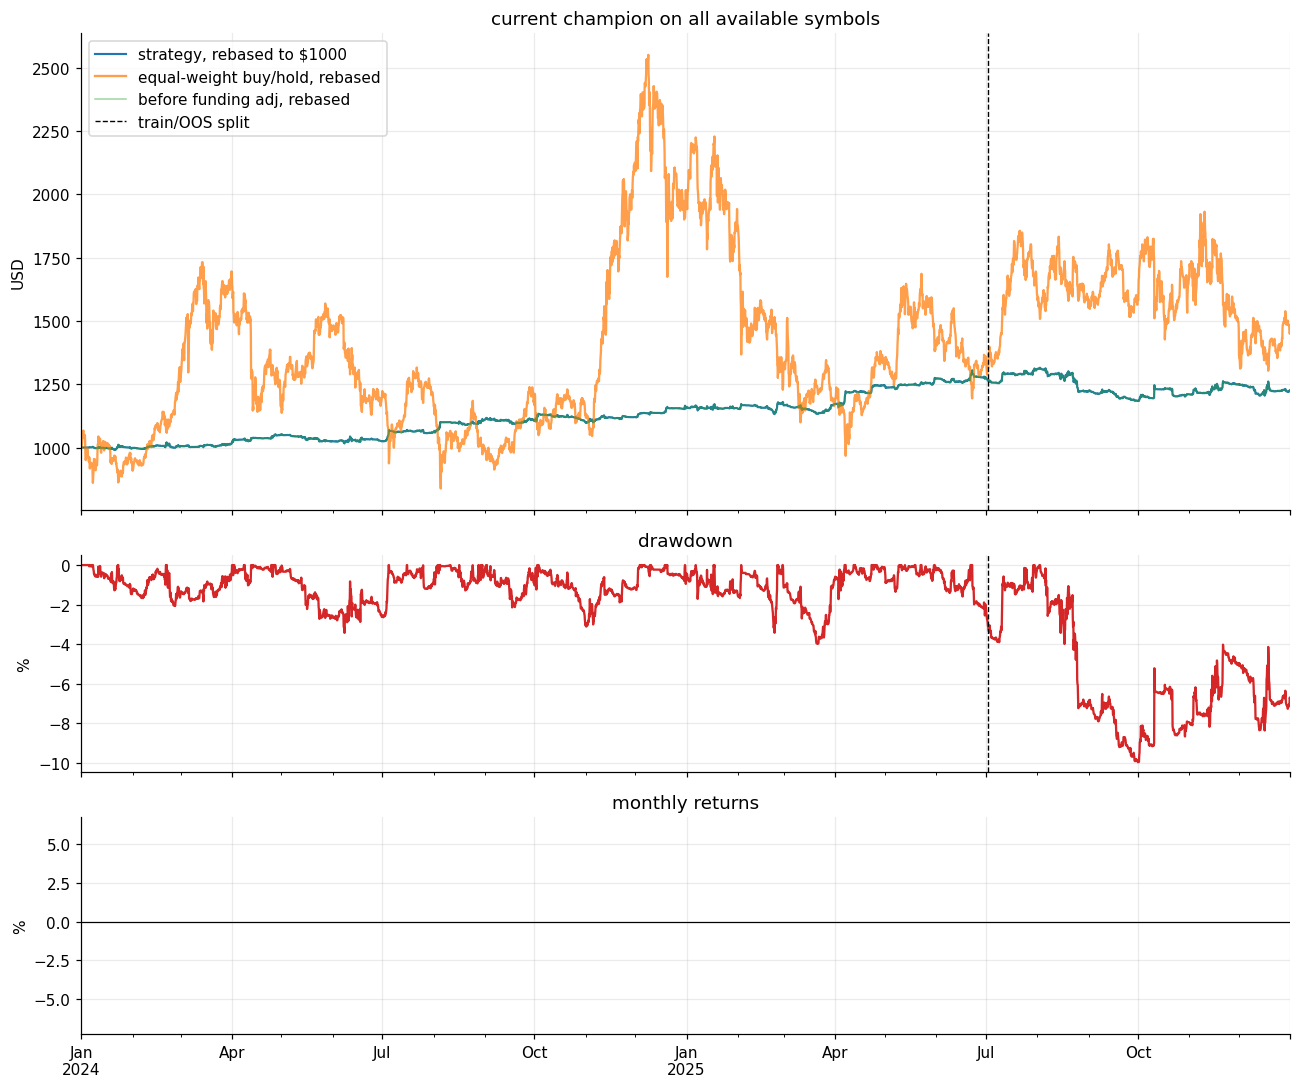

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.0, 1.0]})
equity.plot(ax=ax[0], label="strategy, rebased to $1000", lw=1.4)
benchmark.plot(ax=ax[0], label="equal-weight buy/hold, rebased", alpha=0.75)
raw_equity.plot(ax=ax[0], label="before funding adj, rebased", alpha=0.45, lw=1.0)
ax[0].axvline(cutoff, color="k", lw=0.9, ls="--", label="train/OOS split")
ax[0].set_title("current champion on all available symbols")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")

(dd * 100).plot(ax=ax[1], color="C3")
ax[1].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[1].set_title("drawdown")
ax[1].set_ylabel("%")

mret = monthly_returns(equity) * 100
colors = np.where(mret >= 0, "C2", "C3")
ax[2].bar(mret.index, mret.values, width=20, color=colors, alpha=0.8)
ax[2].axhline(0, color="k", lw=0.8)
ax[2].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[2].set_title("monthly returns")
ax[2].set_ylabel("%")
show("08_current_champion_all_available_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\08_current_champion_all_available_exposure.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/08_current_champion_all_available_exposure.png')

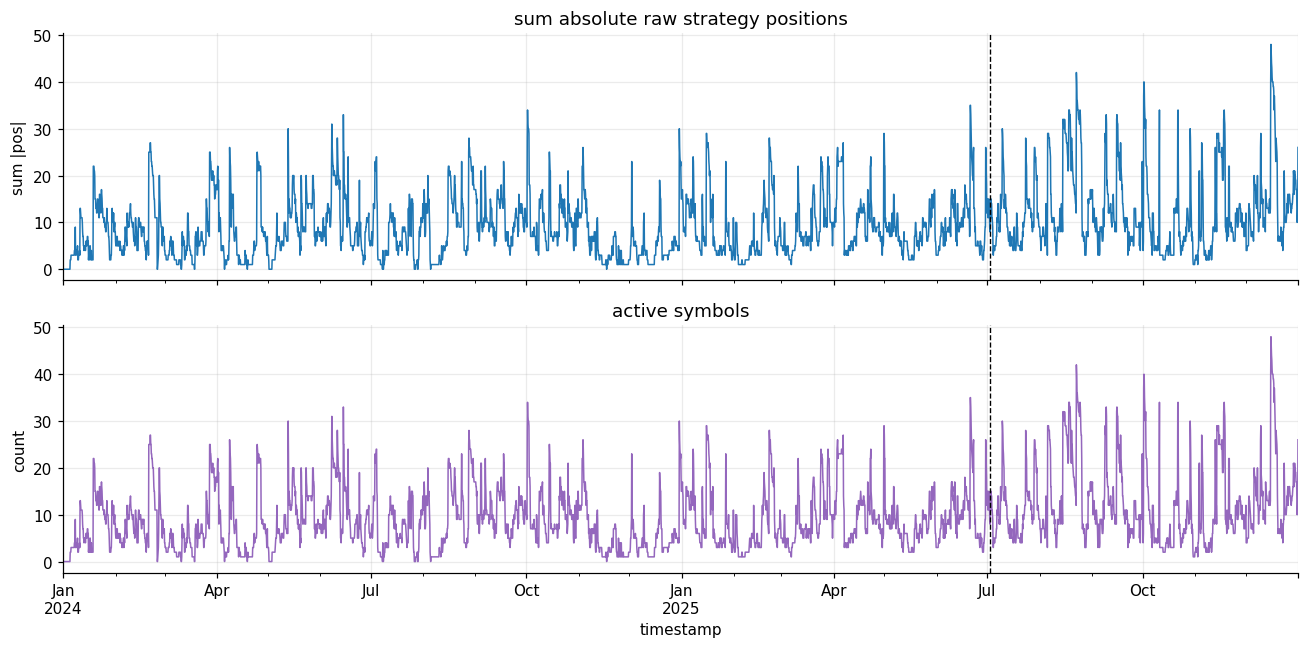

In [6]:
signals = generate_pair_signals(symbols, start, end)
pos = positions_wide(signals).reindex(equity.index).ffill().fillna(0.0)
exposure = pos.abs().sum(axis=1)
active_symbols = (pos != 0).sum(axis=1)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
exposure.plot(ax=ax[0], lw=1.0)
ax[0].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[0].set_title("sum absolute raw strategy positions")
ax[0].set_ylabel("sum |pos|")
active_symbols.plot(ax=ax[1], lw=1.0, color="C4")
ax[1].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[1].set_title("active symbols")
ax[1].set_ylabel("count")
show("08_current_champion_all_available_exposure")

In [7]:
trades = curves["trades"].copy()
print("trades:", len(trades))
trades.head(10)

trades: 4736


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
0,2024-01-23 12:00:00+00:00,2024-01-24 00:00:00+00:00,1000BONKUSDT,Short,13780.179516,0.010286,0.010520,-3.381691,-0.023859,12.0,train,141.736663,5.389900e+07,0.000263
1,2024-02-20 16:00:00+00:00,2024-02-24 04:00:00+00:00,1000BONKUSDT,Short,14455.620612,0.012178,0.011620,7.873752,0.044727,84.0,train,176.040850,3.887109e+07,0.000453
2,2024-02-26 16:00:00+00:00,2024-02-26 20:00:00+00:00,1000BONKUSDT,Long,10498.494727,0.013212,0.013461,2.453105,0.017685,4.0,train,138.709483,6.638348e+07,0.000209
3,2024-03-27 16:00:00+00:00,2024-03-28 04:00:00+00:00,1000BONKUSDT,Short,5543.343399,0.025374,0.026741,-7.735413,-0.054994,12.0,train,140.659358,6.207614e+07,0.000227
4,2024-04-01 08:00:00+00:00,2024-04-02 04:00:00+00:00,1000BONKUSDT,Short,6139.307418,0.025615,0.023812,10.905622,0.069347,20.0,train,157.260822,4.910400e+07,0.000320
5,2024-04-08 12:00:00+00:00,2024-04-09 04:00:00+00:00,1000BONKUSDT,Long,6096.584371,0.024050,0.023404,-4.094108,-0.027923,16.0,train,146.620639,2.361996e+07,0.000621
6,2024-04-09 16:00:00+00:00,2024-04-12 16:00:00+00:00,1000BONKUSDT,Short,7713.671214,0.022239,0.017163,38.982717,0.227250,72.0,train,171.541105,2.436333e+07,0.000704
7,2024-05-06 16:00:00+00:00,2024-05-11 16:00:00+00:00,1000BONKUSDT,Short,7504.571990,0.024787,0.023306,10.920295,0.058705,120.0,train,186.018668,1.069144e+08,0.000174
8,2024-05-13 04:00:00+00:00,2024-05-13 12:00:00+00:00,1000BONKUSDT,Short,6350.141535,0.022805,0.024098,-8.374525,-0.057830,8.0,train,144.813195,1.030814e+08,0.000140
9,2024-05-13 16:00:00+00:00,2024-05-14 00:00:00+00:00,1000BONKUSDT,Long,6188.172139,0.023947,0.023257,-4.434111,-0.029922,8.0,train,148.189755,1.030814e+08,0.000144


In [8]:
if len(trades):
    by_symbol = trades.groupby("symbol").agg(
        n=("symbol", "size"),
        pnl_quote=("pnl_quote", "sum"),
        avg_return=("return_pct", "mean"),
        win_rate=("return_pct", lambda s: (s > 0).mean()),
        avg_duration_h=("duration_hours", "mean"),
    ).sort_values("pnl_quote", ascending=False)
    display(by_symbol.head(30))
    display(by_symbol.tail(30))
    display(trades.tail(10))
else:
    print("No trades in this period.")

,n,pnl_quote,avg_return,win_rate,avg_duration_h
symbol,,,,,
SUIUSDT,73,261.756738,0.020853,0.589041,32.328767
TIAUSDT,77,183.603145,0.012447,0.480519,33.454545
AAVEUSDT,99,179.297369,0.010335,0.545455,36.929293
AVAXUSDT,87,150.689237,0.010308,0.586207,38.114943
SOLUSDT,100,145.978762,0.008646,0.530000,34.080000
ETHUSDT,138,136.552915,0.005602,0.492754,34.347826
TAIKOUSDT,71,135.059649,0.011212,0.563380,32.619718
JUPUSDT,75,128.486462,0.011055,0.466667,36.320000
TRUMPUSDT,36,107.187319,0.015784,0.416667,38.222222


,n,pnl_quote,avg_return,win_rate,avg_duration_h
symbol,,,,,
ZECUSDT,89,12.726072,-0.000578,0.438202,31.730337
XLMUSDT,112,12.273406,0.000010,0.428571,36.000000
BCHUSDT,119,11.559746,0.000492,0.470588,32.941176
LTCUSDT,121,6.831401,0.000712,0.454545,30.181818
TONUSDT,100,6.790848,0.000595,0.430000,29.480000
ICPUSDT,97,6.212049,0.000036,0.463918,31.958763
LABUSDT,2,-0.607979,-0.001623,0.500000,10.000000
ARBUSDT,94,-1.320273,-0.001640,0.361702,30.127660
PUMPFUNUSDT,8,-1.942904,-0.000866,0.625000,42.000000


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
4726,2025-08-14 16:00:00+00:00,2025-08-19 16:00:00+00:00,ZECUSDT,Short,6.095386,36.906476,35.243161,9.896664,0.043993,120.0,oos,224.959231,2.554482e+06,0.008806
4727,2025-08-20 08:00:00+00:00,2025-08-21 16:00:00+00:00,ZECUSDT,Long,4.855442,38.260419,40.053702,8.498043,0.045745,32.0,oos,185.771258,3.044502e+06,0.006102
4728,2025-09-03 12:00:00+00:00,2025-09-04 04:00:00+00:00,ZECUSDT,Long,4.175210,42.428222,40.529810,-8.116774,-0.045819,16.0,oos,177.146744,1.786179e+06,0.009918
4729,2025-09-06 20:00:00+00:00,2025-09-07 00:00:00+00:00,ZECUSDT,Long,3.539350,47.564756,46.765323,-3.013100,-0.017898,4.0,oos,168.348331,3.934216e+06,0.004279
4730,2025-09-08 04:00:00+00:00,2025-09-10 00:00:00+00:00,ZECUSDT,Long,3.741413,49.075635,48.578323,-2.061600,-0.011228,44.0,oos,183.612241,4.749863e+06,0.003866
4731,2025-09-12 20:00:00+00:00,2025-09-14 00:00:00+00:00,ZECUSDT,Long,3.453206,49.661341,53.414202,12.763632,0.074427,28.0,oos,171.490828,2.552995e+06,0.006717
4732,2025-09-22 08:00:00+00:00,2025-09-23 16:00:00+00:00,ZECUSDT,Short,3.550363,47.979269,52.946045,-17.830930,-0.104676,32.0,oos,170.343804,3.075817e+06,0.005538
4733,2025-12-24 16:00:00+00:00,2025-12-27 12:00:00+00:00,ZECUSDT,Long,0.398296,443.623286,513.330518,27.554456,0.155945,68.0,oos,176.693237,1.185104e+08,0.000149
4734,2025-12-28 16:00:00+00:00,2025-12-29 12:00:00+00:00,ZECUSDT,Long,0.335798,527.259046,525.221479,-0.878594,-0.004962,20.0,oos,177.052781,1.417880e+08,0.000125
4735,2025-12-31 16:00:00+00:00,2025-12-31 20:00:00+00:00,ZECUSDT,Short,0.334881,508.899105,511.700294,-1.032339,-0.006058,4.0,oos,170.420650,1.303729e+08,0.000131


In [9]:
print(json.dumps(clean_metrics(result), indent=2, default=str))

{
  "strategy": "volume_weighted_breakout",
  "params": {
    "breakout_lookback": 8,
    "volume_ma": 20,
    "volume_mult": 1.9,
    "flat_trend_span": 60,
    "flat_slope_bars": 12,
    "flat_slope_abs": 0.005,
    "atr_period": 14,
    "exhaustion_bars": 6,
    "max_prior_move": 0.08,
    "follow_volume_mult": 1.2,
    "follow_bars": 3,
    "short_cluster_min": 3,
    "short_cluster_prior_move": -0.045,
    "short_cluster_core": [
      "BTCUSDT",
      "ETHUSDT",
      "SOLUSDT",
      "AVAXUSDT"
    ],
    "take_atr": 2.5,
    "max_hold_bars": 30
  },
  "symbols": [
    "1000BONKUSDT",
    "1000PEPEUSDT",
    "AAVEUSDT",
    "ADAUSDT",
    "AERGOUSDT",
    "AIGENSYNUSDT",
    "ALGOUSDT",
    "ALLOUSDT",
    "APTUSDT",
    "ARBUSDT",
    "AVAXUSDT",
    "BASEDUSDT",
    "BCHUSDT",
    "BEATUSDT",
    "BIRBUSDT",
    "BNBUSDT",
    "BOTUSDT",
    "BREVUSDT",
    "BTCUSDT",
    "CAPUSDT",
    "CLUSDT",
    "CRVUSDT",
    "DASHUSDT",
    "DOGEUSDT",
    "DOTUSDT",
    "DRAMUSDT",
   